# **<font size="70">Data Science Project</font>**
# **<font size="70">Moein Sarvi - 401100885</font>**
<font size="5">link of Kaggle notebook : https://www.kaggle.com/code/moeinasarvi/steel-defect-clustering</font>

# **<font size="30">Original Pipeline</font>**

## <font size="7">PreProcessing</font>

### CLAHE + Resize

In [1]:
import os
from pathlib import Path
import numpy as np
import skimage.io
import skimage.exposure
import skimage.transform
from skimage.util import img_as_ubyte  

# Input dataset root (Kaggle)
DATA_ROOT = Path("/kaggle/input/neu-surface-defect-database/NEU-DET")

# Collect all .jpg images from train + validation (across 6 classes)
files = sorted(DATA_ROOT.glob("**/*.jpg"), key=lambda f: f.name)
print("Total images found:", len(files))  # should be 1800

# Output directories for preprocessed images
OUT_HISTEQ = Path("/kaggle/working/images_histeq_resize")
OUT_RESIZE = Path("/kaggle/working/images_resize")
OUT_HISTEQ.mkdir(parents=True, exist_ok=True)
OUT_RESIZE.mkdir(parents=True, exist_ok=True)

def preprocess_and_save(inpath, outdir, eq_hist=True):
    """
    Preprocess images for VGG16:
    - load grayscale
    - CLAHE (optional, eq_hist=True)
    - resize to 224x224
    - convert back to uint8
    - save to output dir
    """
    name = Path(inpath).name
    im = skimage.io.imread(inpath, as_gray=True)              # load as grayscale
    im = skimage.img_as_float32(im)                           # float [0,1]
    if eq_hist:
        im = skimage.exposure.equalize_adapthist(im)          # CLAHE
    im = skimage.transform.resize(im, (224,224), anti_aliasing=True)  # resize
    im = img_as_ubyte(im)                                     # back to uint8
    skimage.io.imsave(outdir / name, im)                      # save
    return

# Process with histogram equalization
for fp in files:
    preprocess_and_save(fp, OUT_HISTEQ, eq_hist=True)
print("HistEq+Resize saved:", len(list(OUT_HISTEQ.glob("*.jpg"))))

# Process without histogram equalization
for fp in files:
    preprocess_and_save(fp, OUT_RESIZE, eq_hist=False)
print("Resize-only saved:", len(list(OUT_RESIZE.glob("*.jpg"))))


Total images found: 1800
HistEq+Resize saved: 1800
Resize-only saved: 1800


### Extract & Encode Labels

This block reads preprocessed images, extracts their defect labels from filenames, maps them to short class codes, encodes them into integers using LabelEncoder, and saves that encoder. This ensures consistent label handling across experiments and allows us to later translate between class names, codes, and numeric IDs.

In [2]:
import pickle, numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

DIR_HISTEQ = Path("/kaggle/working/images_histeq_resize")
DIR_NOHEQ  = Path("/kaggle/working/images_resize")

files_histeq = sorted(DIR_HISTEQ.glob("*.jpg"), key=lambda p: p.name)
files_noheq  = sorted(DIR_NOHEQ.glob("*.jpg"),  key=lambda p: p.name)
print("Counts:", len(files_histeq), len(files_noheq))  # expect 1800, 1800

def fname_to_rawlabel(p: Path) -> str:
    return p.stem.split("_")[0].lower()

# for Kaggle NEU-DET filenames
MAP = {
    "crazing": "Cr",
    "inclusion": "In",
    "patches": "Pa",
    "pitted": "PS",
    "rolled-in": "RS",
    "scratches": "Sc",
}

def labels_from_files(files):
    raw = [fname_to_rawlabel(p) for p in files]
    lbl = [MAP.get(r, r) for r in raw]
    return np.array(lbl)

labels_histeq = labels_from_files(files_histeq)
labels_noheq  = labels_from_files(files_noheq)

le = LabelEncoder().fit(sorted(np.unique(labels_histeq)))
with open("/kaggle/working/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Classes:", list(le.classes_))  # should be ['Cr','In','Pa','PS','RS','Sc']


Counts: 1800 1800
Classes: ['Cr', 'In', 'PS', 'Pa', 'RS', 'Sc']


## <font size="7">Feature Extraction</font>

In [3]:
import numpy as np, pickle, time
from tqdm import trange
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from pathlib import Path

# Choose what to run now
RUN_LAYERS = ["fc1", "fc2", "block5_pool", "block5_conv3"]   # change to ["fc1"] if you want only FC1

# Build base once
base = VGG16(weights="imagenet", include_top=True)
EXTRACTORS = {ln: Model(inputs=base.input, outputs=base.get_layer(ln).output) for ln in RUN_LAYERS}

def extract_layer_features(files, extractor, batch_size=32):
    N = len(files)
    out = []
    for i in trange(0, N, batch_size):
        batch_paths = files[i:i+batch_size]
        arr = np.stack([img_to_array(load_img(p, target_size=(224,224))) for p in batch_paths], axis=0)
        arr = preprocess_input(arr)
        f = extractor.predict(arr, verbose=0)
        out.append(f.reshape(len(batch_paths), -1))
    return np.vstack(out)

def run_and_save(files, labels, variant_tag):
    for ln in RUN_LAYERS:
        npy_path = Path(f"/kaggle/working/features_{variant_tag}_{ln}.npy")
        pkl_path = Path(f"/kaggle/working/features_{variant_tag}_{ln}.pickle")

        if npy_path.exists() and pkl_path.exists():
            print(f"[{variant_tag}] {ln}: already exists → skip")
            continue

        print(f"\n[{variant_tag}] Extracting layer: {ln}  (expected dims: "
              f"{'4096' if ln in ['fc1','fc2'] else '25088' if ln=='block5_pool' else '100352'})")
        t0 = time.time()
        feats = extract_layer_features(files, EXTRACTORS[ln], batch_size=32)
        print(f"Features shape: {feats.shape}  | time: {time.time()-t0:.1f}s")

        np.save(npy_path, feats)

        meta = {
            "filenames": [str(p) for p in files],
            "labels_str": labels.tolist(),
            "labels_int": le.transform(labels).tolist(),
            "layer_name": ln,
            "variant": variant_tag,
            "shape": feats.shape,
        }
        with open(pkl_path, "wb") as f:
            pickle.dump(meta, f)

        print(f"Saved: {npy_path}  and  {pkl_path}")


2025-08-17 23:36:41.818684: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755473802.002747      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755473802.052113      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1755473814.342013      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
run_and_save(files_histeq, labels_histeq, variant_tag="histeq")


[histeq] Extracting layer: fc1  (expected dims: 4096)


  0%|          | 0/57 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1755473821.518982      98 service.cc:148] XLA service 0x790bc41054e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755473821.523811      98 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1755473821.660821      98 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1755473829.397834      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 57/57 [00:22<00:00,  2.50it/s]


Features shape: (1800, 4096)  | time: 22.8s
Saved: /kaggle/working/features_histeq_fc1.npy  and  /kaggle/working/features_histeq_fc1.pickle

[histeq] Extracting layer: fc2  (expected dims: 4096)


100%|██████████| 57/57 [00:13<00:00,  4.34it/s]


Features shape: (1800, 4096)  | time: 13.1s
Saved: /kaggle/working/features_histeq_fc2.npy  and  /kaggle/working/features_histeq_fc2.pickle

[histeq] Extracting layer: block5_pool  (expected dims: 25088)


100%|██████████| 57/57 [00:12<00:00,  4.68it/s]


Features shape: (1800, 25088)  | time: 12.2s
Saved: /kaggle/working/features_histeq_block5_pool.npy  and  /kaggle/working/features_histeq_block5_pool.pickle

[histeq] Extracting layer: block5_conv3  (expected dims: 100352)


100%|██████████| 57/57 [00:12<00:00,  4.62it/s]


Features shape: (1800, 100352)  | time: 12.6s
Saved: /kaggle/working/features_histeq_block5_conv3.npy  and  /kaggle/working/features_histeq_block5_conv3.pickle


In [5]:
run_and_save(files_noheq,  labels_noheq,  variant_tag="no_histeq") 


[no_histeq] Extracting layer: fc1  (expected dims: 4096)


100%|██████████| 57/57 [00:10<00:00,  5.24it/s]


Features shape: (1800, 4096)  | time: 10.9s
Saved: /kaggle/working/features_no_histeq_fc1.npy  and  /kaggle/working/features_no_histeq_fc1.pickle

[no_histeq] Extracting layer: fc2  (expected dims: 4096)


100%|██████████| 57/57 [00:10<00:00,  5.25it/s]


Features shape: (1800, 4096)  | time: 10.9s
Saved: /kaggle/working/features_no_histeq_fc2.npy  and  /kaggle/working/features_no_histeq_fc2.pickle

[no_histeq] Extracting layer: block5_pool  (expected dims: 25088)


100%|██████████| 57/57 [00:10<00:00,  5.26it/s]


Features shape: (1800, 25088)  | time: 10.9s
Saved: /kaggle/working/features_no_histeq_block5_pool.npy  and  /kaggle/working/features_no_histeq_block5_pool.pickle

[no_histeq] Extracting layer: block5_conv3  (expected dims: 100352)


100%|██████████| 57/57 [00:11<00:00,  5.07it/s]


Features shape: (1800, 100352)  | time: 11.5s
Saved: /kaggle/working/features_no_histeq_block5_conv3.npy  and  /kaggle/working/features_no_histeq_block5_conv3.pickle


Block below loads saved features and ground-truth labels so you we can continue with PCA → k-means → evaluation, without re-running the model

In [6]:
# --- imports
import numpy as np, pandas as pd, pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.optimize import linear_sum_assignment

# --- load features (FC1 + HistEq) and metadata you saved in the previous step
FEAT_NPY  = Path("/kaggle/working/features_histeq_fc1.npy")
FEAT_META = Path("/kaggle/working/features_histeq_fc1.pickle")

X = np.load(FEAT_NPY)  # (1800, 4096)
with open(FEAT_META, "rb") as f:
    meta = pickle.load(f)

files   = np.array(meta["filenames"])
labels  = np.array(meta["labels_str"])     # strings like 'Cr','In','Pa','PS','RS','Sc'
y_gt    = np.array(meta["labels_int"])     # integers via label encoder
classes = sorted(np.unique(labels), key=lambda s: s.upper())

X.shape, len(files), len(y_gt), classes


((1800, 4096), 1800, 1800, ['Cr', 'In', 'Pa', 'PS', 'RS', 'Sc'])

## <font size="7">PCA</font>

variance preserved by 50 components: 0.733


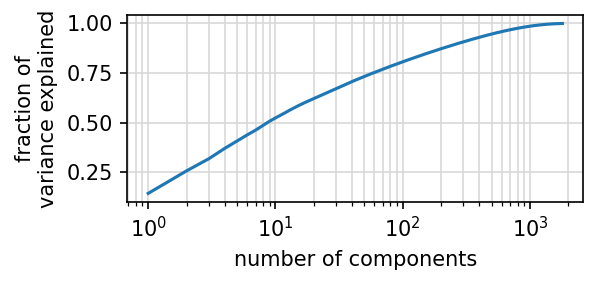

In [7]:
# Fit PCA (no component limit) to view cumulative explained variance
pca_full = PCA(svd_solver="full")
_ = pca_full.fit(X)
var_cum = np.cumsum(pca_full.explained_variance_ratio_)

print(f"variance preserved by 50 components: {var_cum[49]:.3f}")

# Plot (like the paper)
fig, ax = plt.subplots(figsize=(4,2), dpi=150)
ax.grid(True, which='both', color=np.ones(3)*0.85)
ax.plot(range(1, len(var_cum)+1), var_cum, lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('number of components')
ax.set_ylabel('fraction of\nvariance explained')
plt.tight_layout()
plt.show()


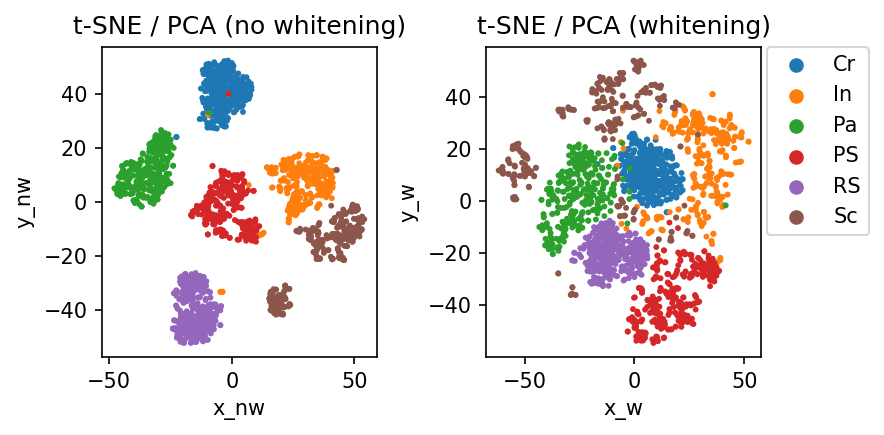

In [8]:
# Fit PCA with and without whitening (k=50 as in the notebook)
pca_w  = PCA(n_components=50, svd_solver="full", whiten=True,  random_state=42)
pca_nw = PCA(n_components=50, svd_solver="full", whiten=False, random_state=42)

X_w  = pca_w.fit_transform(X)   # whitened
X_nw = pca_nw.fit_transform(X)  # not whitened

# 2D t-SNE of both projections (for plots only)
tsne_nw = TSNE(n_components=2, random_state=12214, init="pca", learning_rate="auto")
tsne_w  = TSNE(n_components=2, random_state=654753, init="pca", learning_rate="auto")

X_nw_tsne = tsne_nw.fit_transform(X_nw)
X_w_tsne  = tsne_w.fit_transform(X_w)

df = pd.DataFrame({
    "file": files,
    "x_nw": X_nw_tsne[:,0], "y_nw": X_nw_tsne[:,1],
    "x_w":  X_w_tsne[:,0],  "y_w":  X_w_tsne[:,1],
    "label": labels
})

fig, ax = plt.subplots(1,2, figsize=(6,3), dpi=150)
sns.scatterplot(data=df, x="x_nw", y="y_nw", hue="label", hue_order=classes, ax=ax[0], s=8, linewidth=0)
sns.scatterplot(data=df, x="x_w",  y="y_w",  hue="label", hue_order=classes, ax=ax[1], s=8, linewidth=0)
ax[0].get_legend().remove()
ax[1].legend(bbox_to_anchor=(1.02,1), borderaxespad=0.)
ax[0].set_title("t-SNE / PCA (no whitening)")
ax[1].set_title("t-SNE / PCA (whitening)")
plt.tight_layout(); plt.show()


## <font size="7">Implementing K-Means Cluster</font>

### Hungarian_match function

implementing hungarian_match for guessing class that each cluster represents

In [9]:
import numpy as np
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

def hungarian_match(y_true, y_pred, n_classes):
    """
    Map k-means cluster IDs to ground-truth IDs (0..n_classes-1).
    Works when n_clusters != n_classes (e.g., 7 clusters vs 6 classes).
    """
    pred_labels = np.sort(np.unique(y_pred))               # actual cluster IDs present
    C = contingency_matrix(y_true, y_pred, eps=None)       # shape (n_true, n_pred)
    cost = C.max() - C
    r, c = linear_sum_assignment(cost)                     # match as many as possible

    mapping = {pred_labels[c_i]: r_i for r_i, c_i in zip(r, c)}

    # Map any unmatched cluster to the true class with max count in that column
    unmatched = [cl for cl in pred_labels if cl not in mapping]
    for cl in unmatched:
        col_idx = np.where(pred_labels == cl)[0][0]
        mapping[cl] = int(np.argmax(C[:, col_idx]))

    y_mapped = np.array([mapping[cl] for cl in y_pred], dtype=int)
    return y_mapped, mapping, C


### Implementing with one starting point

inertia: 80419.08
Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

          Cr      0.987     1.000     0.993       300
          In      0.971     0.993     0.982       300
          Pa      0.993     0.997     0.995       300
          PS      1.000     0.990     0.995       300
          RS      1.000     1.000     1.000       300
          Sc      1.000     0.970     0.985       300

    accuracy                          0.992      1800
   macro avg      0.992     0.992     0.992      1800
weighted avg      0.992     0.992     0.992      1800



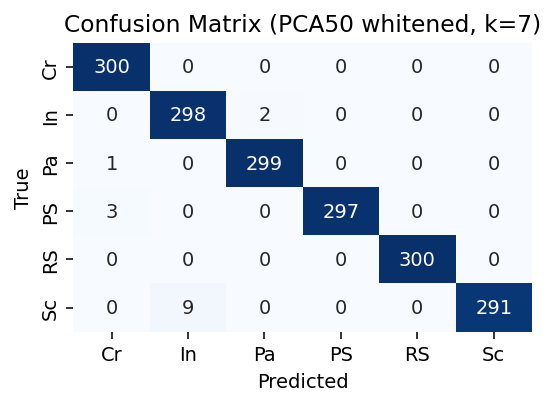

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns, matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=7, init="k-means++", n_init=500, random_state=2149673460)
kmeans.fit(X_w)

y_pred, mapping, Crect = hungarian_match(y_gt, kmeans.labels_, n_classes=len(classes))

print(f"inertia: {kmeans.inertia_:.2f}")
print("Accuracy:", accuracy_score(y_gt, y_pred))
print(classification_report(
    y_gt, y_pred,
    labels=list(range(len(classes))), target_names=classes, digits=3))

cm = confusion_matrix(y_gt, y_pred, labels=list(range(len(classes))))
fig, ax = plt.subplots(figsize=(4,3), dpi=140)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, cbar=False, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (PCA50 whitened, k=7)")
plt.tight_layout(); plt.show()


### Check Repeatablity + Effect of Whitening

This code tests how repeatable clustering is with whitening (multiple seeds) and compares it directly to a single run without whitening, both in terms of accuracy and confusion patterns.

Those seeds are just controlling the random initialization of the k-means centroids.

K-means starts by placing k centroids randomly (here using k-means++ strategy, which is smarter but still involves randomness).

If centroids start in “good” spots → fast convergence, high accuracy.

If they start in “bad” spots → might converge to a local minimum with worse accuracy.

What this loop does is simply by running k-means 10 times with different seeds we check how much accuracy fluctuates between runs.

The average, best, worst outcomes → a measure of repeatability/stability.

This is especially important for whitened PCA features, because whitening tends to flatten the variance across dimensions, making k-means more sensitive to initialization noise.

Accuracies: [0.975556 0.992778 0.978889 0.992222 0.987778 0.977222 0.988889 0.991111
 0.981667 0.991667]
10 runs -> avg: 0.9858 | std: 0.0064 | min: 0.9756
              precision    recall  f1-score   support

          Cr      0.955     0.997     0.976       300
          In      0.942     0.917     0.929       300
          Pa      0.924     0.967     0.945       300
          PS      0.993     0.927     0.959       300
          RS      0.974     1.000     0.987       300
          Sc      0.997     0.973     0.985       300

    accuracy                          0.963      1800
   macro avg      0.964     0.963     0.963      1800
weighted avg      0.964     0.963     0.963      1800



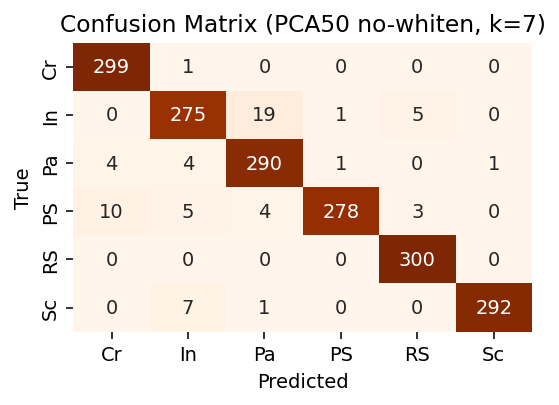

In [11]:
# Repeatability on whitened X_w
accs = []
rng = np.random.RandomState(987654321)
for seed in rng.randint(2**32, size=10):
    km = KMeans(n_clusters=7, init="k-means++", n_init=500, random_state=int(seed))
    km.fit(X_w)
    y_map, _, _ = hungarian_match(y_gt, km.labels_, n_classes=len(classes))
    accs.append(accuracy_score(y_gt, y_map))
accs = np.array(accs)
print("Accuracies:", accs.round(6))
print(f"10 runs -> avg: {accs.mean():.4f} | std: {accs.std():.4f} | min: {accs.min():.4f}")

# No-whitening comparison on X_nw
km_nw = KMeans(n_clusters=7, init="k-means++", n_init=500, random_state=13)
km_nw.fit(X_nw)
y_nw_map, _, _ = hungarian_match(y_gt, km_nw.labels_, n_classes=len(classes))

print(classification_report(
    y_gt, y_nw_map,
    labels=list(range(len(classes))), target_names=classes, digits=3))

cm_nw = confusion_matrix(y_gt, y_nw_map, labels=list(range(len(classes))))
fig, ax = plt.subplots(figsize=(4,3), dpi=140)
sns.heatmap(cm_nw, annot=True, fmt="d", cmap="Oranges",
            xticklabels=classes, yticklabels=classes, cbar=False, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (PCA50 no-whiten, k=7)")
plt.tight_layout(); plt.show()


# <font size="20">Sensitivity Analysis</font>

## <font size="6.5">Histogram Equalization</font>

In [12]:
# --- imports
import numpy as np, pandas as pd, pickle, os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

DIR_NOHEQ = Path("/kaggle/working/images_resize")  # from notebook 01
FEAT_NPY  = Path("/kaggle/working/features_no_histeq_fc1.npy")
FEAT_META = Path("/kaggle/working/features_no_histeq_fc1.pickle")
LE_PATH   = Path("/kaggle/working/label_encoder.pkl")

# helper to map folder names -> short labels (same mapping as earlier)
MAP = {"crazing":"Cr","inclusion":"In","patches":"Pa","pitted_surface":"PS",
       "rolled-in_scale":"RS","scratches":"Sc"}

files = sorted(DIR_NOHEQ.glob("*.jpg"), key=lambda p: p.name)
assert len(files) == 1800, f"Expected 1800 images, found {len(files)}"

def fname_to_rawlabel(p: Path) -> str:
    return p.stem.split("_")[0].lower()

labels_str = np.array([MAP.get(fname_to_rawlabel(p), fname_to_rawlabel(p)) for p in files])

# load label encoder from earlier step
with open(LE_PATH, "rb") as f:
    le = pickle.load(f)
classes = list(le.classes_)

# --- robust normalization for both schemes (words or short codes) ---
def normalize_label(s: str) -> str:
    s = s.strip().lower()
    # long names
    if s in {"crazing"}: return "Cr"
    if s in {"inclusion"}: return "In"
    if s in {"patches"}: return "Pa"
    if s in {"pitted_surface", "pitted"}: return "PS"
    if s in {"rolled-in_scale", "rolled-in"}: return "RS"
    if s in {"scratches"}: return "Sc"
    # short 2-letter (or similar) codes found in some file sets
    if s in {"cr"}: return "Cr"
    if s in {"in"}: return "In"
    if s in {"pa"}: return "Pa"
    if s in {"ps", "pi"}: return "PS"   # some sets use "pi" for pitted
    if s in {"rs"}: return "RS"
    if s in {"sc"}: return "Sc"
    raise ValueError(f"Unrecognized label prefix: {s}")

raw_prefixes = [fname_to_rawlabel(p) for p in files]
labels_str = np.array([normalize_label(s) for s in raw_prefixes])

# sanity check
print("Unique normalized labels:", sorted(np.unique(labels_str)))
y_gt = le.transform(labels_str)


# compute FC1 only if missing; otherwise load
if not FEAT_NPY.exists():
    print("Computing FC1 features (no-histeq) …")
    base = VGG16(weights="imagenet", include_top=True)
    fc1_extractor = Model(inputs=base.input, outputs=base.get_layer("fc1").output)

    B = 32
    feats = []
    for i in range(0, len(files), B):
        batch = [img_to_array(load_img(p, target_size=(224,224))) for p in files[i:i+B]]
        x = preprocess_input(np.stack(batch, axis=0))
        f = fc1_extractor.predict(x, verbose=0)
        feats.append(f)
    X = np.vstack(feats)                   # (1800, 4096)

    np.save(FEAT_NPY, X)
    with open(FEAT_META, "wb") as f:
        pickle.dump({
            "filenames":[str(p) for p in files],
            "labels_str": labels_str.tolist(),
            "labels_int": y_gt.tolist(),
            "layer_name":"fc1",
            "variant":"no_histeq",
            "shape": X.shape
        }, f)
    print("Saved:", FEAT_NPY, "and", FEAT_META)
else:
    print("Loading cached features:", FEAT_NPY)
    X = np.load(FEAT_NPY)
    with open(FEAT_META, "rb") as f:
        meta = pickle.load(f)
    # trust labels from encoder we just loaded (ensures same ordering)
    files = [Path(s) for s in meta["filenames"]]
    labels_str = np.array(meta["labels_str"])
    y_gt = np.array(meta["labels_int"])

print("X shape:", X.shape, " | classes:", classes)

Unique normalized labels: ['Cr', 'In', 'PS', 'Pa', 'RS', 'Sc']
Loading cached features: /kaggle/working/features_no_histeq_fc1.npy
X shape: (1800, 4096)  | classes: ['Cr', 'In', 'PS', 'Pa', 'RS', 'Sc']


variance preserved by 50 components: 0.765


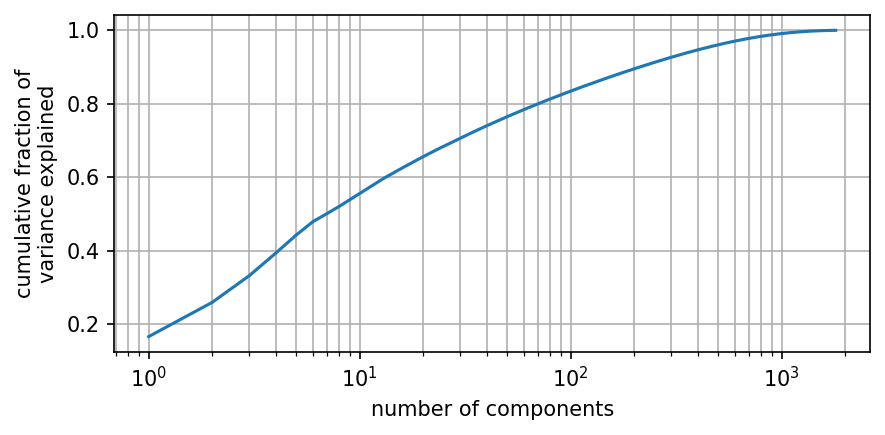

In [13]:
pca_full = PCA(svd_solver="full")
_ = pca_full.fit(X)
var_cum = np.cumsum(pca_full.explained_variance_ratio_)
print(f"variance preserved by 50 components: {var_cum[49]:.3f}")

fig, ax = plt.subplots(figsize=(6,3), dpi=150)
ax.grid(True, which="both")
ax.plot(range(1, len(var_cum)+1), var_cum)
ax.set_xscale("log"); ax.set_xlabel("number of components")
ax.set_ylabel("cumulative fraction of\nvariance explained")
plt.tight_layout(); plt.show()

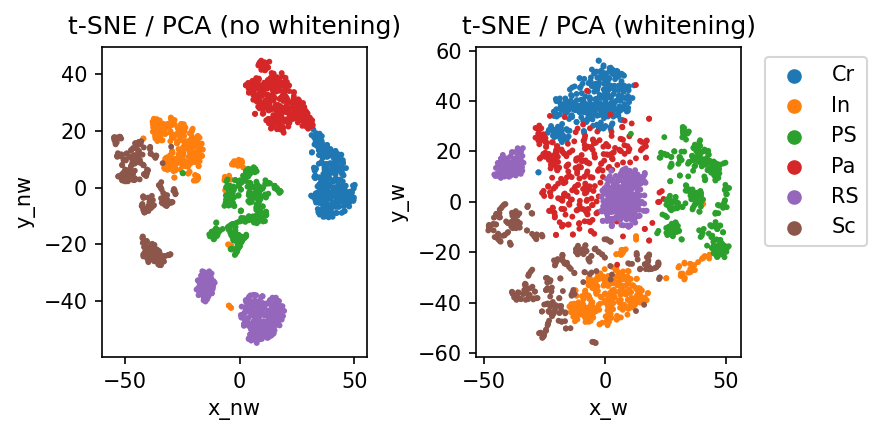

In [14]:
pca_w  = PCA(n_components=50, svd_solver="full", whiten=True,  random_state=42)
pca_nw = PCA(n_components=50, svd_solver="full", whiten=False, random_state=42)
X_w  = pca_w.fit_transform(X)
X_nw = pca_nw.fit_transform(X)

tsne_nw = TSNE(n_components=2, random_state=605196619, init="pca", learning_rate="auto")
tsne_w  = TSNE(n_components=2, random_state=3618296892, init="pca", learning_rate="auto")
XY_nw = tsne_nw.fit_transform(X_nw)
XY_w  = tsne_w.fit_transform(X_w)

df = pd.DataFrame({
    "x_nw": XY_nw[:,0], "y_nw": XY_nw[:,1],
    "x_w":  XY_w[:,0],  "y_w":  XY_w[:,1],
    "label": labels_str
})

fig, ax = plt.subplots(1,2, figsize=(6,3), dpi=150)
sns.scatterplot(data=df, x="x_nw", y="y_nw", hue="label", hue_order=classes, ax=ax[0], s=8, linewidth=0)
sns.scatterplot(data=df, x="x_w",  y="y_w",  hue="label", hue_order=classes, ax=ax[1], s=8, linewidth=0)
ax[0].get_legend().remove()
ax[1].legend(bbox_to_anchor=(1.05,1))
ax[0].set_title("t-SNE / PCA (no whitening)")
ax[1].set_title("t-SNE / PCA (whitening)")
plt.tight_layout(); plt.show()


In [15]:
def hungarian_match(y_true, y_pred, n_classes):
    pred_labels = np.sort(np.unique(y_pred))
    C = contingency_matrix(y_true, y_pred, eps=None)     # 6×k
    cost = C.max() - C
    r, c = linear_sum_assignment(cost)
    mapping = {pred_labels[c_i]: r_i for r_i, c_i in zip(r, c)}
    # map any unmatched cluster to the row with max count in that column
    unmatched = [cl for cl in pred_labels if cl not in mapping]
    for cl in unmatched:
        col = np.where(pred_labels == cl)[0][0]
        mapping[cl] = int(np.argmax(C[:, col]))
    y_mapped = np.array([mapping[cl] for cl in y_pred], dtype=int)
    return y_mapped, mapping, C


inertia: 80732.90
Accuracy: 0.8472222222222222
              precision    recall  f1-score   support

          Cr      1.000     1.000     1.000       300
          In      0.573     0.887     0.696       300
          PS      0.881     0.693     0.776       300
          Pa      1.000     1.000     1.000       300
          RS      0.860     1.000     0.924       300
          Sc      1.000     0.503     0.670       300

    accuracy                          0.847      1800
   macro avg      0.886     0.847     0.844      1800
weighted avg      0.886     0.847     0.844      1800



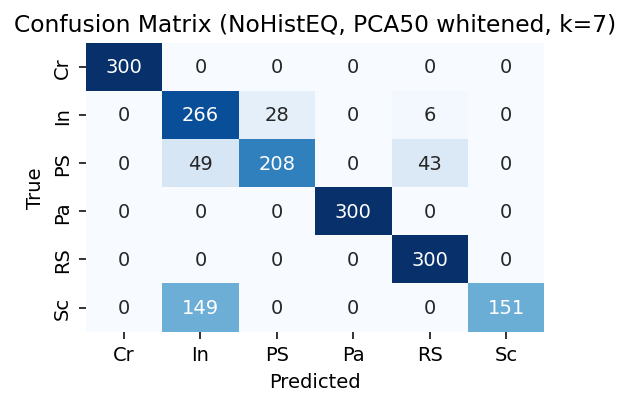

In [16]:
kmeans = KMeans(n_clusters=7, init="k-means++", n_init=500, random_state=3831647997)
kmeans.fit(X_w)

y_pred, mapping, Crect = hungarian_match(y_gt, kmeans.labels_, n_classes=len(classes))

print(f"inertia: {kmeans.inertia_:.2f}")
print("Accuracy:", accuracy_score(y_gt, y_pred))
print(classification_report(
    y_gt, y_pred, labels=list(range(len(classes))), target_names=classes, digits=3))

cm = confusion_matrix(y_gt, y_pred, labels=list(range(len(classes))))
fig, ax = plt.subplots(figsize=(4,3), dpi=140)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes, cbar=False, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix (NoHistEQ, PCA50 whitened, k=7)")
plt.tight_layout(); plt.show()


In [17]:
accs = []
rng = np.random.RandomState(987654321)
for seed in rng.randint(2**32, size=10):
    km = KMeans(n_clusters=7, init="k-means++", n_init=500, random_state=int(seed))
    km.fit(X_w)
    y_map, _, _ = hungarian_match(y_gt, km.labels_, n_classes=len(classes))
    accs.append(accuracy_score(y_gt, y_map))

accs = np.array(accs)
print("Accuracies:", accs.round(6))
print(f"10 runs -> avg: {accs.mean():.4f} | std: {accs.std():.4f} | min: {accs.min():.4f}")


Accuracies: [0.871667 0.87     0.85     0.931111 0.934444 0.945    0.822778 0.932222
 0.961111 0.876111]
10 runs -> avg: 0.8994 | std: 0.0444 | min: 0.8228


max accuracy: 0.944
num clusters: 9


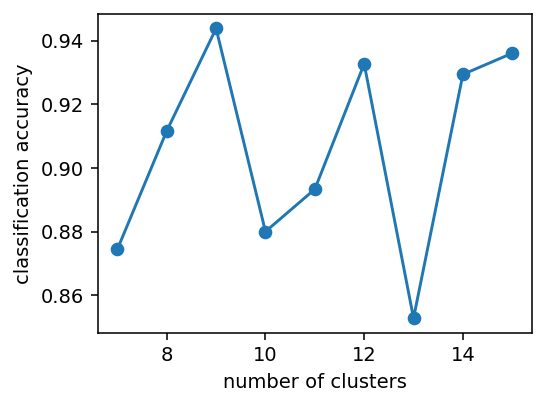

In [18]:
k_values = np.arange(7, 16)
acc_k = []

rng = np.random.RandomState(723271629)
for k, seed in zip(k_values, rng.randint(2**32, size=len(k_values))):
    km = KMeans(n_clusters=int(k), init="k-means++", n_init=500, random_state=int(seed))
    km.fit(X_w)
    y_map, _, _ = hungarian_match(y_gt, km.labels_, n_classes=len(classes))
    acc_k.append(accuracy_score(y_gt, y_map))

acc_k = np.array(acc_k)
best_idx = int(np.argmax(acc_k))
print("max accuracy: {:.3f}\nnum clusters: {}".format(acc_k.max(), k_values[best_idx]))

fig, ax = plt.subplots(figsize=(4,3), dpi=140)
ax.plot(k_values, acc_k, marker="o")
ax.set_xlabel("number of clusters"); ax.set_ylabel("classification accuracy")
plt.tight_layout(); plt.show()


## <font size="7">Layer Selection</font>


ANALYZING LAYER: fc2
Loading features from: features_histeq_fc2.npy
Applying PCA with 50 components...

--- Clustering on WHITENED PCA space (k=[7]) ---
k=7   -> Accuracy: 0.9406

Best PCA Accuracy for fc2: 0.9406 (at k=7)


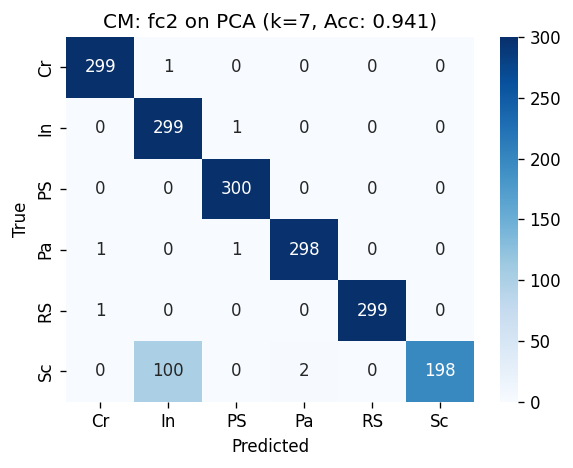


ANALYZING LAYER: block5_pool
Loading features from: features_histeq_block5_pool.npy
Applying PCA with 110 components...

--- Clustering on WHITENED PCA space (k=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]) ---
k=6   -> Accuracy: 0.4733
k=7   -> Accuracy: 0.5122
k=8   -> Accuracy: 0.6883
k=9   -> Accuracy: 0.7261
k=10  -> Accuracy: 0.8489
k=11  -> Accuracy: 0.9089
k=12  -> Accuracy: 0.8467
k=13  -> Accuracy: 0.8450
k=14  -> Accuracy: 0.8233
k=15  -> Accuracy: 0.8922
k=16  -> Accuracy: 0.9283
k=17  -> Accuracy: 0.8356
k=18  -> Accuracy: 0.7967
k=19  -> Accuracy: 0.7983
k=20  -> Accuracy: 0.9306
k=21  -> Accuracy: 0.8133
k=22  -> Accuracy: 0.8089
k=23  -> Accuracy: 0.8750
k=24  -> Accuracy: 0.8617

Best PCA Accuracy for block5_pool: 0.9306 (at k=20)


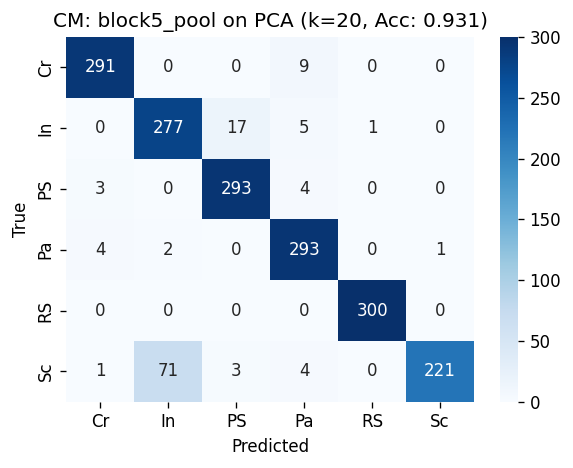


--- Clustering on T-SNE space (k=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]) ---
Running t-SNE (this may take a moment)...
k=6   -> Accuracy: 0.8422
k=7   -> Accuracy: 0.9744
k=8   -> Accuracy: 0.9461
k=9   -> Accuracy: 0.9606
k=10  -> Accuracy: 0.9383
k=11  -> Accuracy: 0.9378
k=12  -> Accuracy: 0.9383
k=13  -> Accuracy: 0.9606
k=14  -> Accuracy: 0.9678
k=15  -> Accuracy: 0.9561
k=16  -> Accuracy: 0.9672
k=17  -> Accuracy: 0.9583
k=18  -> Accuracy: 0.9650
k=19  -> Accuracy: 0.9711
k=20  -> Accuracy: 0.9711
k=21  -> Accuracy: 0.9583
k=22  -> Accuracy: 0.9583
k=23  -> Accuracy: 0.9506
k=24  -> Accuracy: 0.9422

Best t-SNE Accuracy for block5_pool: 0.9744 (at k=7)


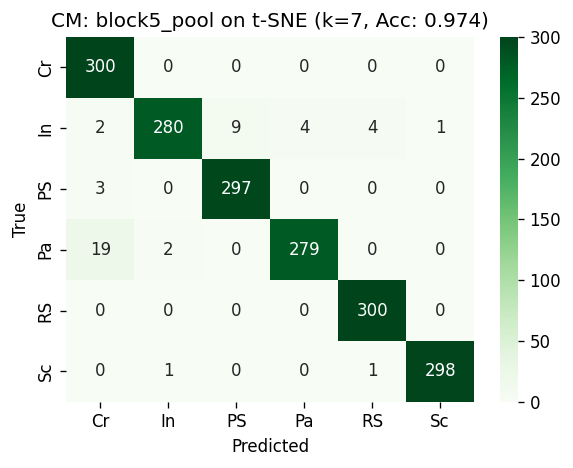


ANALYZING LAYER: block5_conv3
Loading features from: features_histeq_block5_conv3.npy
Applying PCA with 200 components...

--- Clustering on WHITENED PCA space (k=[6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]) ---
k=6   -> Accuracy: 0.6006
k=7   -> Accuracy: 0.4206
k=8   -> Accuracy: 0.4117
k=9   -> Accuracy: 0.5989
k=10  -> Accuracy: 0.5744
k=11  -> Accuracy: 0.5633
k=12  -> Accuracy: 0.5678
k=13  -> Accuracy: 0.3806
k=14  -> Accuracy: 0.6572
k=15  -> Accuracy: 0.4639
k=16  -> Accuracy: 0.6061
k=17  -> Accuracy: 0.6794
k=18  -> Accuracy: 0.6028
k=19  -> Accuracy: 0.6117

Best PCA Accuracy for block5_conv3: 0.6794 (at k=17)


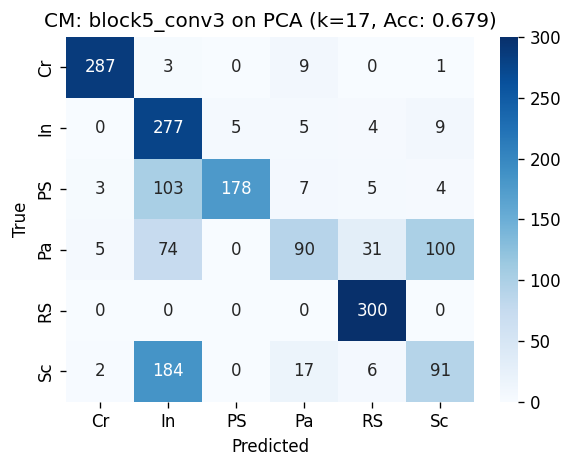


FINAL SUMMARY OF LAYER SENSITIVITY ANALYSIS
Layer & Space             | Best Accuracy   | Optimal k
------------------------------------------------------------
fc2_pca                   | 0.9406           | 7
block5_pool_pca           | 0.9306           | 20
block5_pool_tsne          | 0.9744           | 7
block5_conv3_pca          | 0.6794           | 17


In [12]:
# ===================================================================
# FINAL SCRIPT FOR VGG16 LAYER SENSITIVITY ANALYSIS
# ===================================================================

# --- 1. Imports and Setup ---
import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

# --- 2. Configuration ---
# Central configuration for all layers. Edit paths and parameters here.
BASE_DIR = Path("/kaggle/working")
FIGURES_DIR = BASE_DIR / "Figures"
FIGURES_DIR.mkdir(exist_ok=True)

# This dictionary drives the entire analysis
CONFIG = {
    "fc2": {
        "features_path": BASE_DIR / "features_histeq_fc2.npy",
        "meta_path": BASE_DIR / "features_histeq_fc2.pickle",
        "n_components": 50,
        "cluster_on": "pca", # 'pca' or 'tsne' or 'both'
        "k_values": [7],     # Just test the best k
    },
    "block5_pool": {
        "features_path": BASE_DIR / "features_histeq_block5_pool.npy",
        "meta_path": BASE_DIR / "features_histeq_block5_pool.pickle",
        "n_components": 110,
        "cluster_on": "both", # Paper tests both PCA and t-SNE
        "k_values": list(range(6, 25)),
    },
    "block5_conv3": {
        "features_path": BASE_DIR / "features_histeq_block5_conv3.npy",
        "meta_path": BASE_DIR / "features_histeq_block5_conv3.pickle",
        "n_components": 200,
        "cluster_on": "pca",
        "k_values": list(range(6, 20)),
    }
}

# --- 3. Helper Functions ---

def hungarian_match(y_true, y_pred):
    """Matches predicted cluster labels to true labels via the Hungarian algorithm."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    contingency = contingency_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-contingency) # Maximize matches
    
    mapping = {pred_idx: true_idx for pred_idx, true_idx in zip(col_ind, row_ind)}
    
    # Map any unassigned clusters to the most frequent true label in that cluster
    unassigned_preds = set(np.unique(y_pred)) - set(col_ind)
    for pred_idx in unassigned_preds:
        true_labels_in_cluster = y_true[y_pred == pred_idx]
        if len(true_labels_in_cluster) > 0:
            most_common_true_label = np.bincount(true_labels_in_cluster).argmax()
            mapping[pred_idx] = most_common_true_label
        else: # Handle empty clusters if they occur
            mapping[pred_idx] = -1 # Or some other placeholder

    return np.array([mapping.get(p, -1) for p in y_pred])


def load_data_packet(features_path, meta_path):
    """Loads features and metadata for a given layer."""
    print(f"Loading features from: {features_path.name}")
    X = np.load(features_path)
    with open(meta_path, "rb") as f:
        meta = pickle.load(f)
    
    # Flatten features if they are convolutional (e.g., shape [1800, 7, 7, 512])
    if X.ndim > 2:
        X = X.reshape(len(X), -1)
        
    y_str = np.asarray(meta.get("labels_str") or meta.get("labels"))
    return X, y_str

# --- 4. Main Analysis Loop ---

# Load the Label Encoder once
with open(BASE_DIR / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)
classes_ordered = list(le.classes_)

# Store best results for a final summary
final_results = {}

for layer_name, params in CONFIG.items():
    print("\n" + "="*60)
    print(f"ANALYZING LAYER: {layer_name}")
    print("="*60)

    # --- Data Loading and Preprocessing ---
    X, y_str = load_data_packet(params["features_path"], params["meta_path"])
    y_true = le.transform(y_str)
    
    # --- PCA Transformation ---
    n_comp = params["n_components"]
    print(f"Applying PCA with {n_comp} components...")
    pca_w = PCA(n_components=n_comp, svd_solver='full', whiten=True, random_state=42)
    X_pca_w = pca_w.fit_transform(X) # Whitened for K-Means
    
    pca_nw = PCA(n_components=n_comp, svd_solver='full', whiten=False, random_state=42)
    X_pca_nw = pca_nw.fit_transform(X) # Non-whitened for t-SNE

    # --- K-Means Clustering on PCA space ---
    if params["cluster_on"] in ["pca", "both"]:
        print(f"\n--- Clustering on WHITENED PCA space (k={params['k_values']}) ---")
        best_acc_pca = 0
        best_cm_pca = None
        best_k_pca = -1
        
        rs = np.random.RandomState(seed=2296093342) # Consistent seeds
        for k, seed in zip(params["k_values"], rs.randint(2**32, size=len(params["k_values"]))):
            kmeans = KMeans(n_clusters=k, init='k-means++', n_init=100, random_state=seed)
            kmeans.fit(X_pca_w)
            y_pred_matched = hungarian_match(y_true, kmeans.labels_)
            acc = accuracy_score(y_true, y_pred_matched)
            print(f"k={k:<3} -> Accuracy: {acc:.4f}")
            if acc > best_acc_pca:
                best_acc_pca = acc
                best_cm_pca = confusion_matrix(y_true, y_pred_matched)
                best_k_pca = k
        
        print(f"\nBest PCA Accuracy for {layer_name}: {best_acc_pca:.4f} (at k={best_k_pca})")
        final_results[f"{layer_name}_pca"] = {"accuracy": best_acc_pca, "k": best_k_pca}
        
        # Plot and save the best confusion matrix
        plt.figure(figsize=(5, 4), dpi=120)
        sns.heatmap(best_cm_pca, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes_ordered, yticklabels=classes_ordered)
        plt.title(f"CM: {layer_name} on PCA (k={best_k_pca}, Acc: {best_acc_pca:.3f})")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"cm_{layer_name}_pca.png")
        plt.show()

    # --- K-Means Clustering on t-SNE space (only if specified) ---
    if params["cluster_on"] in ["tsne", "both"]:
        print(f"\n--- Clustering on T-SNE space (k={params['k_values']}) ---")
        print("Running t-SNE (this may take a moment)...")
        tsne = TSNE(n_components=2, random_state=12213, init='pca', learning_rate='auto')
        X_tsne = tsne.fit_transform(X_pca_nw) # t-SNE on non-whitened PCA
        
        best_acc_tsne = 0
        best_cm_tsne = None
        best_k_tsne = -1

        rs = np.random.RandomState(seed=3081759952) # Consistent seeds
        for k, seed in zip(params["k_values"], rs.randint(2**32, size=len(params["k_values"]))):
            kmeans = KMeans(n_clusters=k, init='k-means++', n_init=100, random_state=seed)
            kmeans.fit(X_tsne)
            y_pred_matched = hungarian_match(y_true, kmeans.labels_)
            acc = accuracy_score(y_true, y_pred_matched)
            print(f"k={k:<3} -> Accuracy: {acc:.4f}")
            if acc > best_acc_tsne:
                best_acc_tsne = acc
                best_cm_tsne = confusion_matrix(y_true, y_pred_matched)
                best_k_tsne = k
        
        print(f"\nBest t-SNE Accuracy for {layer_name}: {best_acc_tsne:.4f} (at k={best_k_tsne})")
        final_results[f"{layer_name}_tsne"] = {"accuracy": best_acc_tsne, "k": best_k_tsne}

        # Plot and save the best confusion matrix
        plt.figure(figsize=(5, 4), dpi=120)
        sns.heatmap(best_cm_tsne, annot=True, fmt='d', cmap='Greens',
                    xticklabels=classes_ordered, yticklabels=classes_ordered)
        plt.title(f"CM: {layer_name} on t-SNE (k={best_k_tsne}, Acc: {best_acc_tsne:.3f})")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"cm_{layer_name}_tsne.png")
        plt.show()

# --- 5. Final Summary ---
print("\n" + "="*60)
print("FINAL SUMMARY OF LAYER SENSITIVITY ANALYSIS")
print("="*60)
print(f"{'Layer & Space':<25} | {'Best Accuracy':<15} | {'Optimal k'}")
print("-"*60)
for key, result in final_results.items():
    print(f"{key:<25} | {result['accuracy']:.4f}{' ':<10} | {result['k']}")
print("="*60)

## <font size="7">PCA</font>

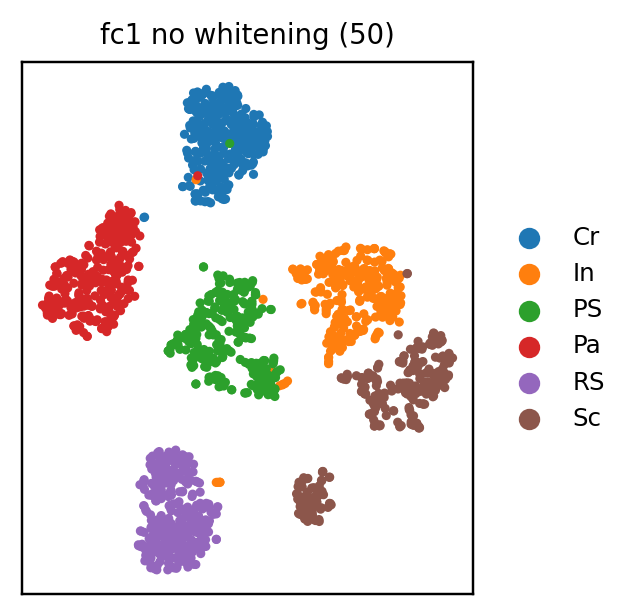

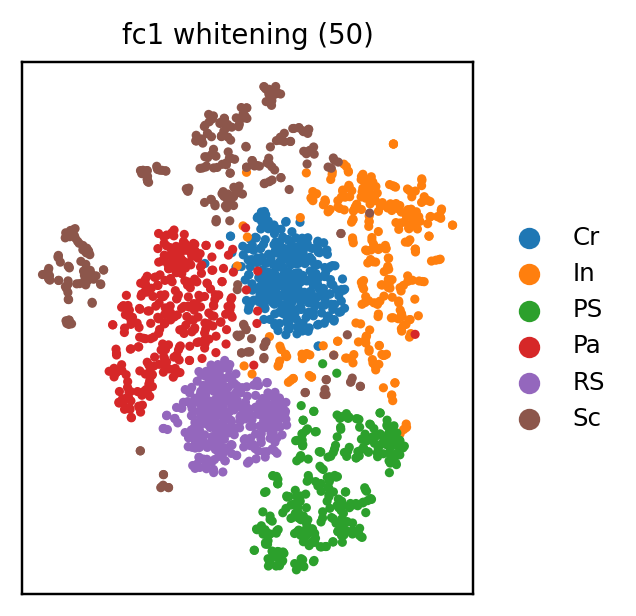

Without whitening (50 comps):
trial 1
inertia: 6732742.00
[[299   1   0   0   0   0]
 [  0 274  19   1   4   2]
 [  4   4 291   1   0   0]
 [ 10   5   4 278   3   0]
 [  0   0   0   0 300   0]
 [  0   6   2   0   0 292]]
Accuracy: 0.963

trial 2
inertia: 6732726.00
[[299   1   0   0   0   0]
 [  0 275  19   0   4   2]
 [  4   4 291   1   0   0]
 [ 10   5   4 278   3   0]
 [  0   0   0   0 300   0]
 [  0   6   2   0   0 292]]
Accuracy: 0.964

trial 3
inertia: 6732726.00
[[299   1   0   0   0   0]
 [  0 275  19   0   4   2]
 [  4   4 291   1   0   0]
 [ 10   5   4 278   3   0]
 [  0   0   0   0 300   0]
 [  0   6   2   0   0 292]]
Accuracy: 0.964

trial 4
inertia: 6732681.50
[[299   1   0   0   0   0]
 [  0 275  19   1   5   0]
 [  4   4 290   1   0   1]
 [  9   5   4 279   3   0]
 [  0   0   0   0 300   0]
 [  0   7   1   0   0 292]]
Accuracy: 0.964

trial 5
inertia: 6732742.50
[[299   1   0   0   0   0]
 [  0 275  19   0   4   2]
 [  3   4 291   1   0   1]
 [ 10   5   4 278   3   0]
 [

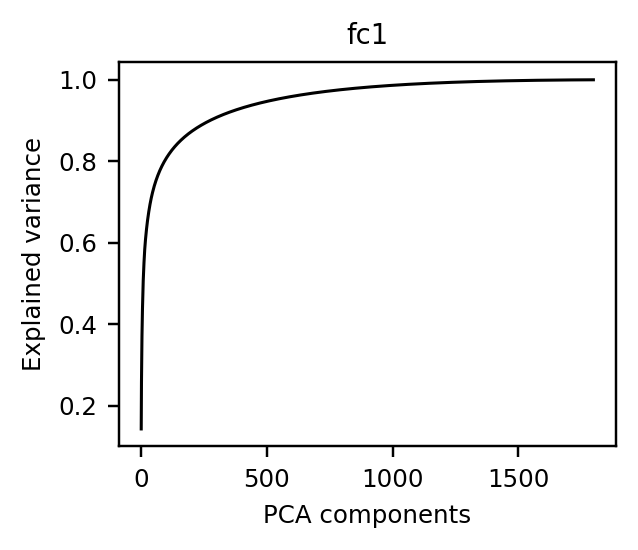

number of components: 1
total fraction of variance: 0.143

number of components: 5
total fraction of variance: 0.407

number of components: 10
total fraction of variance: 0.523

number of components: 20
total fraction of variance: 0.621

number of components: 50
total fraction of variance: 0.733

number of components: 100
total fraction of variance: 0.807

number of components: 250
total fraction of variance: 0.892

number of components: 500
total fraction of variance: 0.947

number of components: 1000
total fraction of variance: 0.986

number of components: 1800
total fraction of variance: 1.000

number of components:    1
number of components:    5
number of components:   10
number of components:   20
number of components:   50
number of components:  100
number of components:  250
number of components:  500
number of components: 1000
number of components: 1800


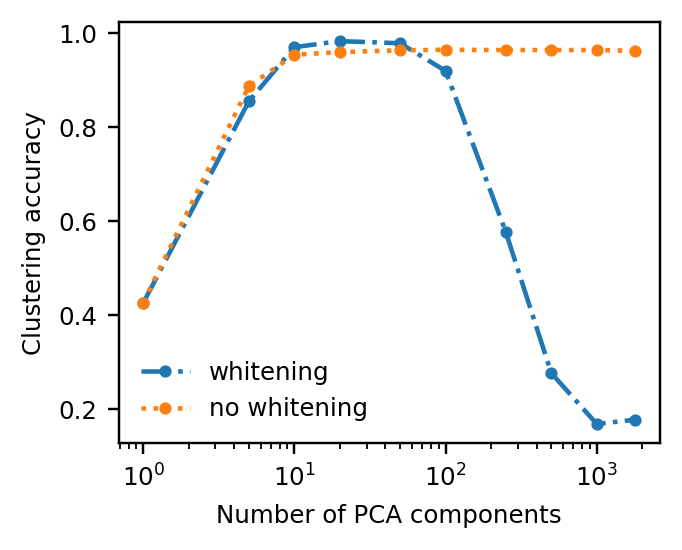

number of components	accuaries (no whitening)	accuracies (whitening)
	   1			0.427				0.426
	   5			0.887				0.855
	  10			0.954				0.970
	  20			0.959				0.983
	  50			0.963				0.978
	 100			0.964				0.919
	 250			0.964				0.577
	 500			0.964				0.277
	1000			0.964				0.169
	1800			0.962				0.178


In [21]:
# --- Sensitivity study: PCA (adapted to /kaggle/working) ---
from pathlib import Path
import numpy as np, pickle, matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

# I/O & figure dirs
WORK = Path("/kaggle/working")
FIGS = WORK / "Figures"; FIGS.mkdir(parents=True, exist_ok=True)
CACHE = WORK / ".neu_cache"; CACHE.mkdir(parents=True, exist_ok=True)

FC1_NPY  = WORK / "features_histeq_fc1.npy"
FC1_META = WORK / "features_histeq_fc1.pickle"
LE_PATH  = WORK / "label_encoder.pkl"

# --- Robust label matcher (Hungarian + extra clusters -> column argmax) ---
def label_matcher(pred_labels, y_true_int):
    pred_labels = np.asarray(pred_labels)
    y_true_int  = np.asarray(y_true_int)
    pred_vals = np.sort(np.unique(pred_labels))
    true_vals = np.sort(np.unique(y_true_int))
    C = contingency_matrix(y_true_int, pred_labels, eps=None)        # (n_true, n_pred)
    r, c = linear_sum_assignment(C.max() - C)                        # maximize matches
    mapping = {pred_vals[c_i]: true_vals[r_i] for r_i, c_i in zip(r, c)}
    # map unmatched predicted clusters to the row with max count in their column
    for pv in pred_vals:
        if pv not in mapping:
            col = np.where(pred_vals == pv)[0][0]
            mapping[pv] = true_vals[int(np.argmax(C[:, col]))]
    return np.array([mapping[v] for v in pred_labels], dtype=int)

# --- Load features + labels ---
X = np.load(FC1_NPY)
with open(FC1_META, "rb") as f: meta = pickle.load(f)
labels = np.asarray(meta.get("labels_str") or meta.get("labels"))

with open(LE_PATH, "rb") as f: le = pickle.load(f)
y_gt = le.transform(labels)
labels_ordered = list(le.classes_)

# --- PCA ± whitening @ 50 comps + t-SNE for both ---
pca = PCA(n_components=50, svd_solver='full', whiten=True,  random_state=42)
pca_nw = PCA(n_components=50, svd_solver='full', whiten=False, random_state=42)
x   = pca.fit_transform(X)
x_nw = pca_nw.fit_transform(X)

tsne = TSNE(n_components=2, random_state=12214)
tsne_w = TSNE(n_components=2, random_state=654753)
x_nw_tsne = tsne.fit_transform(x_nw)
x_w_tsne  = tsne_w.fit_transform(x)

# Small t-SNE plots with class legend
def tsne_scatter(name, Z2, labels):
    fig, ax = plt.subplots(figsize=(3.0, 2.9), dpi=220, facecolor='w')
    sns.scatterplot(x=Z2[:,0], y=Z2[:,1], hue=labels, hue_order=labels_ordered,
                    ax=ax, s=9, linewidth=0, legend="full")
    ax.set_title(name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    leg = ax.legend(title=None, loc='center left', bbox_to_anchor=(1.02, 0.5),
                    frameon=False, fontsize=8)
    plt.tight_layout()
    fig.savefig(FIGS / f"tsne_{name.replace(' ','_')}.png", bbox_inches='tight')
    plt.show()

tsne_scatter("fc1 no whitening (50)", x_nw_tsne, labels)
tsne_scatter("fc1 whitening (50)",    x_w_tsne,  labels)

# --- 5 trials without whitening ---
print("Without whitening (50 comps):")
rs = np.random.RandomState(seed=1115068143)
for i, seed in enumerate(rs.randint(2**32,size=5), start=1):
    kmeans = KMeans(n_clusters=7, init='k-means++', n_init=50, random_state=int(seed))
    kmeans.fit(x_nw)
    y_pred = label_matcher(kmeans.labels_, y_gt)
    CM = confusion_matrix(y_gt, y_pred, labels=np.arange(len(labels_ordered)))
    print(f"trial {i}")
    print(f"inertia: {kmeans.inertia_:.2f}")
    print(CM)
    print("Accuracy: {:.3f}\n".format(CM.trace()/CM.sum()))

# --- variance explained curve (all components, from non-whitened PCA) ---
pca_all_nw = PCA(whiten=False, svd_solver='full').fit(X)
var = pca_all_nw.explained_variance_ratio_.astype(np.float64).cumsum()

fig, ax = plt.subplots(figsize=(3.0, 2.6), dpi=220)
ax.plot(var, '-k', linewidth=1)
ax.set_xlabel("PCA components", fontsize=8)
ax.set_ylabel("Explained variance", fontsize=8)
ax.set_title("fc1", fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# Print variance at specific component counts
nc = [1, 5, 10, 20, 50, 100, 250, 500, 1000, 1800]
for n, v in zip(nc, var[np.asarray(nc)-1]):
    print(f"number of components: {n}\ntotal fraction of variance: {v:.3f}\n")

# --- Sweep number of components; cache results ---
use_cache = True
cache_path = CACHE / "sensitivity_pca_num_components_fc1.pickle"

if (not use_cache) or (not cache_path.is_file()):
    accs_w, accs_nw = [], []
    rs = np.random.RandomState(seed=3731806785)
    seeds1 = rs.randint(2**32, size=len(nc))
    seeds2 = rs.randint(2**32, size=len(nc))

    for c, s1, s2 in zip(nc, seeds1, seeds2):
        print(f"number of components: {c:>4}")
        pca_nw_c = PCA(whiten=False, svd_solver='full', n_components=c)
        pca_w_c  = PCA(whiten=True,  svd_solver='full', n_components=c)
        x_nw_c = pca_nw_c.fit_transform(X)
        x_w_c  = pca_w_c.fit_transform(X)

        km_nw = KMeans(n_clusters=7, init='k-means++', n_init=500, random_state=int(s1)).fit(x_nw_c)
        y_pred_nw = label_matcher(km_nw.labels_, y_gt)
        CM_nw = confusion_matrix(y_gt, y_pred_nw)
        accs_nw.append(CM_nw.trace()/CM_nw.sum())

        km_w  = KMeans(n_clusters=7, init='k-means++', n_init=500, random_state=int(s2)).fit(x_w_c)
        y_pred_w = label_matcher(km_w.labels_, y_gt)
        CM_w  = confusion_matrix(y_gt, y_pred_w)
        accs_w.append(CM_w.trace()/CM_w.sum())

    with open(cache_path, "wb") as f:
        pickle.dump({"nc": nc, "accs_nw": accs_nw, "accs_w": accs_w}, f)
else:
    with open(cache_path, "rb") as f:
        obj = pickle.load(f)
        nc, accs_nw, accs_w = obj["nc"], obj["accs_nw"], obj["accs_w"]

# --- Plot accuracy vs components (log x) ---
fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=220)
ax.plot(nc, accs_w,  '-.o', label='whitening',    markersize=3)
ax.plot(nc, accs_nw, ':o',  label='no whitening', markersize=3)
ax.set_xscale('log')
ax.set_xlabel('Number of PCA components', fontsize=8)
ax.set_ylabel('Clustering accuracy', fontsize=8)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
fig.savefig(FIGS / "pca_n_components_fc1.png", bbox_inches='tight')
plt.show()

print('number of components\taccuaries (no whitening)\taccuracies (whitening)')
for n, nw, w in zip(nc, accs_nw, accs_w):
    print('\t{:>4}\t\t\t{:.3f}\t\t\t\t{:.3f}'.format(n, nw, w))


The drop in accuracy when retaining a high number of whitened PCA components is an expected outcome. Whitening rescales all components to unit variance, which suppresses the dominant, high-variance components (signal) while amplifying the low-variance ones (often noise). When too many components are kept, this process gives noise an equal footing with the signal. Consequently, downstream algorithms like K-Means begin to cluster on these amplified noise dimensions, causing a sharp decline in performance.

## <font size="7">Number of Clusters in K-Means</font>

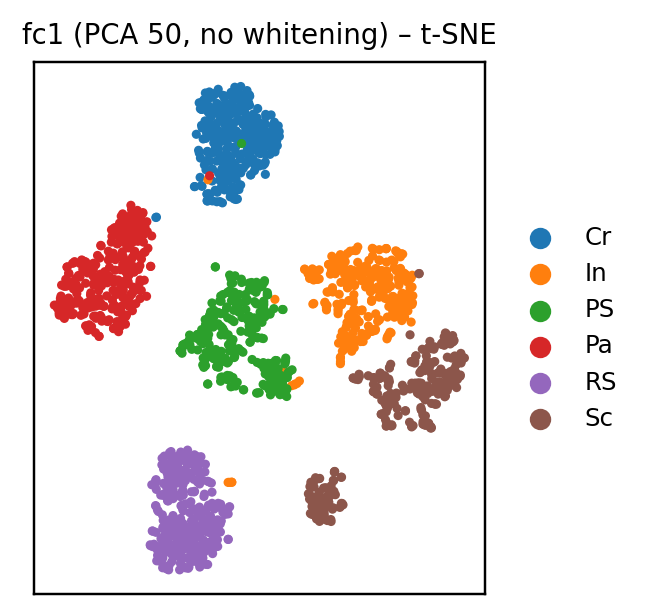

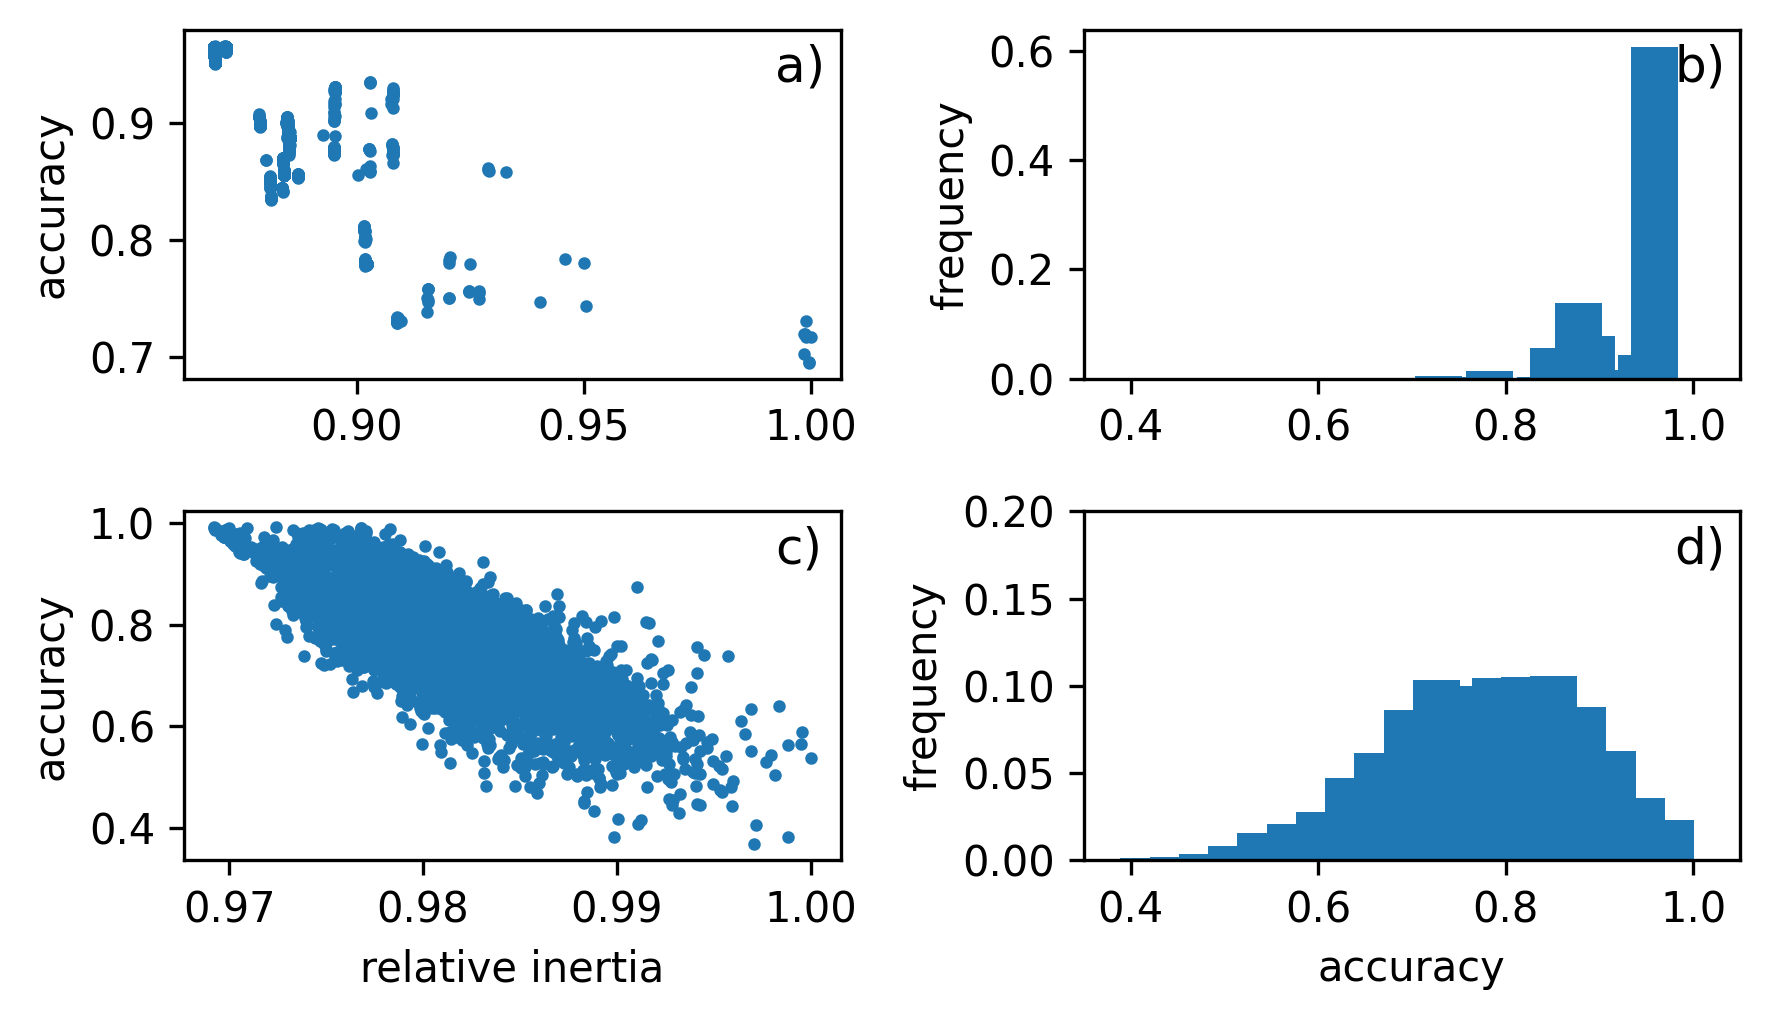

No Whitening
	min acc: 	0.695
	max acc:	0.966
acc-min inertia:	0.962

With Whitening
	min acc: 	0.367
	max acc:	0.992
acc-min inertia:	0.992

No whitening
	top bin accuracy:	0.945
	top bin fraction:	0.608

With whitening
	top bin accuracy:	0.990
	top bin fraction:	0.002
bins_w[hist_w.argmax():hist_w.argmax()+2] -> [0.85116667 0.88238889]

Pearson r correlation between accuracy and inertia
whitening: 	-0.776
no whitening:	-0.858


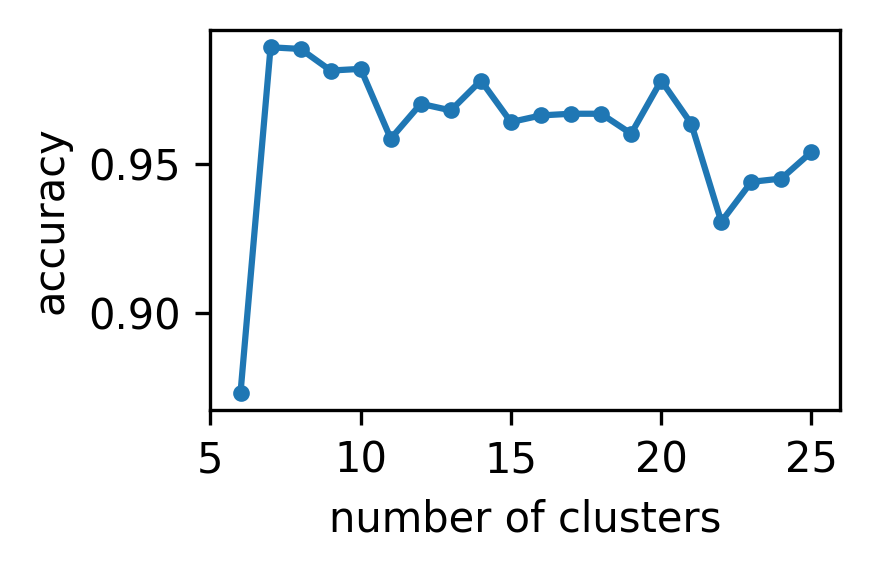

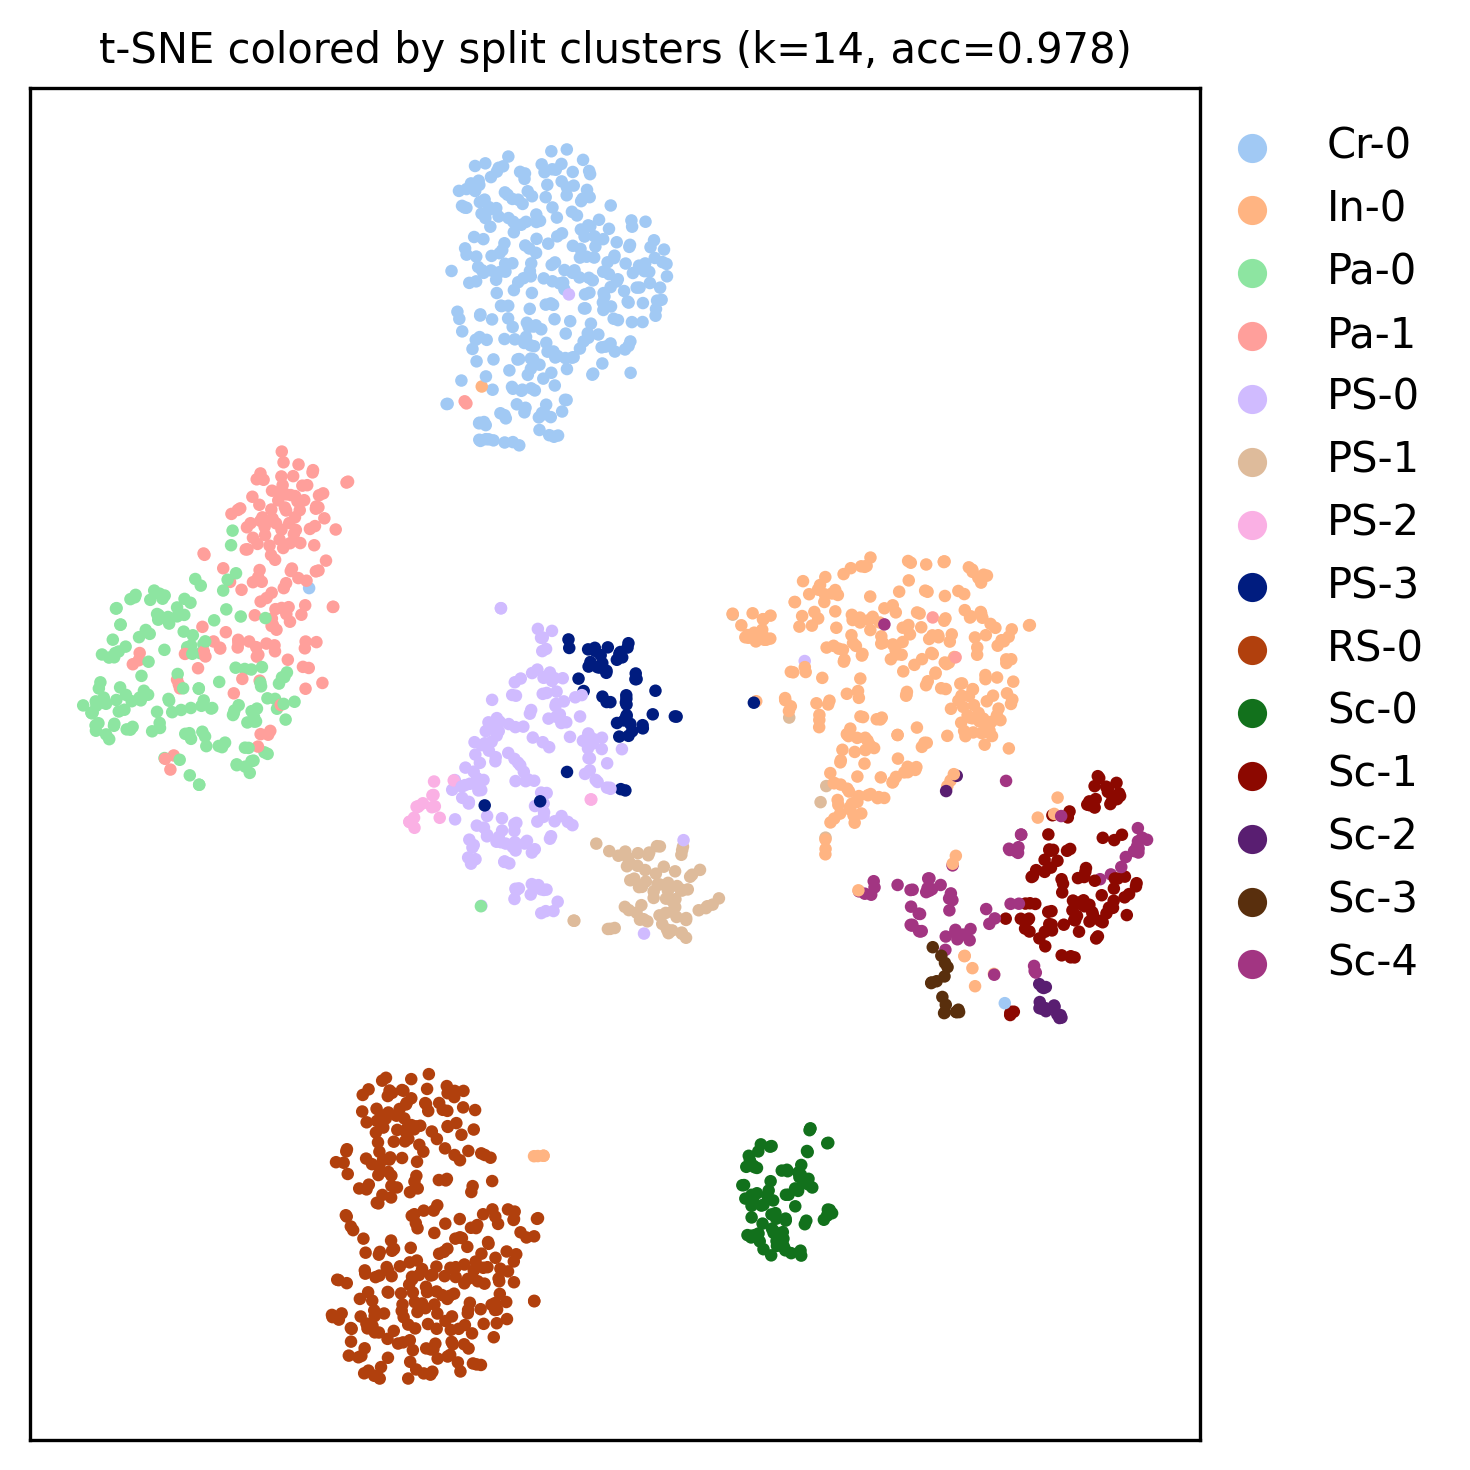

In [13]:
# === Sensitivity study: K-means ===
from pathlib import Path
import numpy as np, pickle
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

# ---------------- Paths & IO ----------------
WORK   = Path("/kaggle/working")
FIGS   = WORK / "Figures";    FIGS.mkdir(parents=True, exist_ok=True)
CACHE  = WORK / ".neu_cache"; CACHE.mkdir(parents=True, exist_ok=True)

FC1_NPY  = WORK / "features_histeq_fc1.npy"
FC1_META = WORK / "features_histeq_fc1.pickle"
LE_PATH  = WORK / "label_encoder.pkl"

assert FC1_NPY.is_file() and FC1_META.is_file(), "fc1 histeq features not found. Run the fc1 extraction first."
assert LE_PATH.is_file(), "label_encoder.pkl not found."

X = np.load(FC1_NPY)
with open(FC1_META, "rb") as f: meta = pickle.load(f)
labels = np.asarray(meta.get("labels_str") or meta.get("labels"))

with open(LE_PATH, "rb") as f: le = pickle.load(f)
labels_ordered = list(le.classes_)
y_gt = le.transform(labels)

# ---------------- Helper: robust label matcher (Hungarian + extra clusters) ----------------
def label_matcher(pred_labels, y_true_int):
    pred_labels = np.asarray(pred_labels)
    y_true_int  = np.asarray(y_true_int)
    pred_vals = np.sort(np.unique(pred_labels))
    true_vals = np.sort(np.unique(y_true_int))
    C = contingency_matrix(y_true_int, pred_labels, eps=None)      # (n_true, n_pred)
    r, c = linear_sum_assignment(C.max() - C)                      # maximize matches
    mapping = {pred_vals[c_i]: true_vals[r_i] for r_i, c_i in zip(r, c)}
    # Map any unmatched predicted cluster to the row with max count in its column
    for pv in pred_vals:
        if pv not in mapping:
            col = np.where(pred_vals == pv)[0][0]
            mapping[pv] = true_vals[int(np.argmax(C[:, col]))]
    return np.array([mapping[v] for v in pred_labels], dtype=int)

# ---------------- PCA (50) + t-SNE (like the paper) ----------------
pca   = PCA(n_components=50, svd_solver='full', whiten=True,  random_state=42)
pca_nw= PCA(n_components=50, svd_solver='full', whiten=False, random_state=42)
x   = pca.fit_transform(X)     # whitened
x_nw= pca_nw.fit_transform(X)  # unwhitened

x_nw_tsne = TSNE(n_components=2, random_state=12214).fit_transform(x_nw)

fig, ax = plt.subplots(figsize=(3.0, 2.9), dpi=220)
sns.scatterplot(x=x_nw_tsne[:,0], y=x_nw_tsne[:,1],
                hue=labels, hue_order=labels_ordered,
                s=9, linewidth=0, legend="full", ax=ax)
ax.set_title("fc1 (PCA 50, no whitening) – t-SNE", fontsize=9)
ax.set_xticks([]); ax.set_yticks([])
leg = ax.legend(title=None, loc='center left', bbox_to_anchor=(1.02, 0.5),
                frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig(FIGS / "kmeans_tsne_fc1_nw50.png", bbox_inches='tight')
plt.show()

# ---------------- Influence of number of initializations (n_init=1) ----------------
N_TESTS = 5000  # heavy but cached (set smaller if you only want a quick dry run)
rs = np.random.RandomState(seed=3688757485)
rs_w  = rs.randint(2**32, size=N_TESTS)
rs_nw = rs.randint(2**32, size=N_TESTS)

cache_inertia = CACHE / "kmeans_acc_vs_inertia.pickle"
use_cache = True

if (not use_cache) or (not cache_inertia.is_file()):
    accs_w  = np.zeros(N_TESTS); inertias_w  = np.zeros(N_TESTS)
    accs_nw = np.zeros(N_TESTS); inertias_nw = np.zeros(N_TESTS)
    for i, (seed_w, seed_nw) in enumerate(zip(rs_w, rs_nw)):
        # Whitening
        km_w = KMeans(n_clusters=7, init='k-means++', n_init=1, random_state=int(seed_w)).fit(x)
        y_pred_w = label_matcher(km_w.labels_, y_gt)
        CM_w = confusion_matrix(y_gt, y_pred_w)
        accs_w[i] = CM_w.trace()/CM_w.sum(); inertias_w[i] = km_w.inertia_
        # No whitening
        km_nw = KMeans(n_clusters=7, init='k-means++', n_init=1, random_state=int(seed_nw)).fit(x_nw)
        y_pred_nw = label_matcher(km_nw.labels_, y_gt)
        CM_nw = confusion_matrix(y_gt, y_pred_nw)
        accs_nw[i] = CM_nw.trace()/CM_nw.sum(); inertias_nw[i] = km_nw.inertia_
    with open(cache_inertia, "wb") as f:
        pickle.dump({"accs_w": accs_w, "accs_nw": accs_nw,
                     "inertias_w": inertias_w, "inertias_nw": inertias_nw}, f)
else:
    with open(cache_inertia, "rb") as f:
        obj = pickle.load(f)
        accs_w, accs_nw = obj["accs_w"], obj["accs_nw"]
        inertias_w, inertias_nw = obj["inertias_w"], obj["inertias_nw"]

# ---------------- Visualize (accuracy vs relative inertia + histograms) ----------------
def format_hist(data, bins):
    hist, edges = np.histogram(data, bins=bins)
    centers = np.asarray([(a+b)/2 for a, b in zip(edges[:-1], edges[1:])])
    return hist, centers

hist_w,  bins_w  = format_hist(accs_w, bins=20)
hist_nw, bins_nw = format_hist(accs_nw, bins=20)

fig, axs = plt.subplots(2, 2, figsize=(6, 3.5), dpi=300, facecolor='w')

ax = axs[0,0]
ax.plot(inertias_nw/np.max(inertias_nw), accs_nw, 'o', markersize=2)
ax.set_ylabel('accuracy')

ax = axs[0,1]
ax.bar(bins_nw, hist_nw/np.sum(hist_nw), width=0.05)
ax.set_xlim([0.35, 1.05]); ax.set_ylabel('frequency')

ax = axs[1,0]
ax.plot(inertias_w/np.max(inertias_w), accs_w, 'o', markersize=2)
ax.set_xlabel('relative inertia'); ax.set_ylabel('accuracy')

ax = axs[1,1]
ax.bar(bins_w, hist_w/np.sum(hist_w), width=0.05)
ax.set_xlim([0.35, 1.05]); ax.set_yticks(np.linspace(0, 0.2, 5))
ax.set_xlabel('accuracy'); ax.set_ylabel('frequency')

for a, title in zip(axs.ravel(), ['a','b','c','d']):
    a.set_title(f"{title})", loc='left', x=0.9, y=0.78)

fig.tight_layout()
fig.savefig(FIGS / "kmeans_n_iter.png", bbox_inches='tight')
plt.show()

# ---------------- Printed summaries (like paper) ----------------
print('No Whitening')
print('\tmin acc: \t{:.3f}\n\tmax acc:\t{:.3f}\nacc-min inertia:\t{:.3f}\n'.format(
    accs_nw.min(), accs_nw.max(), accs_nw[np.argmin(inertias_nw)]))

print('With Whitening')
print('\tmin acc: \t{:.3f}\n\tmax acc:\t{:.3f}\nacc-min inertia:\t{:.3f}'.format(
    accs_w.min(), accs_w.max(), accs_w[np.argmin(inertias_w)]))

print('\nNo whitening')
print('\ttop bin accuracy:\t{:.3f}\n\ttop bin fraction:\t{:.3f}\n'.format(
    bins_nw[-2], hist_nw[-1]/np.sum(hist_nw)))
print('With whitening')
print('\ttop bin accuracy:\t{:.3f}\n\ttop bin fraction:\t{:.3f}'.format(
    0.99, np.mean(accs_w > 0.99)))
print("bins_w[hist_w.argmax():hist_w.argmax()+2] ->", bins_w[np.argmax(hist_w):np.argmax(hist_w)+2])

print('\nPearson r correlation between accuracy and inertia')
print('whitening: \t{:.3f}'.format(pearsonr(inertias_w, accs_w)[0]))
print('no whitening:\t{:.3f}'.format(pearsonr(inertias_nw, accs_nw)[0]))

# ---------------- Influence of number of clusters (k) ----------------
cache_k = CACHE / "kmeans_acc_vs_k.pickle"
use_cache = True

if (not use_cache) or (not cache_k.is_file()):
    k_values = np.arange(6, 26)
    acc_k = np.zeros_like(k_values, dtype=float)
    rs = np.random.RandomState(seed=3689319368)
    for i, (k, state) in enumerate(zip(k_values, rs.randint(2**32, size=len(k_values)))):
        km = KMeans(n_clusters=int(k), init='k-means++', n_init=500, random_state=int(state)).fit(x)  # whitened
        y_pred = label_matcher(km.labels_, y_gt)
        CM = confusion_matrix(y_gt, y_pred)
        acc_k[i] = CM.trace()/CM.sum()
    with open(cache_k, "wb") as f:
        pickle.dump({"k_values": k_values, "acc_k": acc_k}, f)
else:
    with open(cache_k, "rb") as f:
        obj = pickle.load(f)
        k_values, acc_k = obj["k_values"], obj["acc_k"]

fig, ax = plt.subplots(dpi=300, figsize=(3, 2.0))
ax.plot(k_values, acc_k, '-o', markersize=3)
ax.set_xticks(range(5, 26, 5))
ax.set_xlabel('number of clusters'); ax.set_ylabel('accuracy')
plt.tight_layout(); plt.show()

# ---------------- Visualize cluster splitting on t-SNE (choose a k index) ----------------
rs2 = np.random.RandomState(seed=3689319368)
k_ = np.arange(6, 25)
states = rs2.randint(2**32, size=k_.shape)

i = 8  # same as paper (adjust if you want a different k)
km = KMeans(n_clusters=int(k_[i]), init='k-means++', n_init=500, random_state=int(states[i])).fit(x)  # whitened
y_pred = label_matcher(km.labels_, y_gt)
CM = confusion_matrix(y_gt, y_pred)
acc = CM.trace()/CM.sum()

# Map each raw kmeans cluster to "<class>-<idx within class>"
cluster_mapper = {}
for p in np.unique(y_pred):
    y_clusters = km.labels_[y_pred == p]
    for idx, value in enumerate(np.unique(y_clusters)):
        cluster_mapper[value] = '{}-{}'.format(le.inverse_transform([p])[0], idx)

hue = [cluster_mapper[cid] for cid in km.labels_]
hue_order = sorted(cluster_mapper.values(), key=lambda s: s.upper())

palette = np.concatenate((sns.color_palette('pastel', 7), sns.color_palette('dark', 7)), axis=0)
pal_dict = dict(zip(hue_order, palette[:len(hue_order)]))

fig, ax = plt.subplots(dpi=300, figsize=(5, 5))
sns.scatterplot(x=x_nw_tsne[:,0], y=x_nw_tsne[:,1],
                hue=hue, hue_order=hue_order, palette=pal_dict,
                s=9, linewidth=0, ax=ax, legend="full")
ax.legend(loc='upper center', bbox_to_anchor=(1.1, 1.0), frameon=False)
ax.set_title(f"t-SNE colored by split clusters (k={k_[i]}, acc={acc:.3f})", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
fig.savefig(FIGS / f"kmeans_cluster_splits_k{k_[i]}.png", bbox_inches='tight')
plt.show()


## <font size="7">Cross Validation</font>

So far, we have fit the clusters to all of the data and then reported the accuuracy.

But what if we wanted to use this model in a real QC setting, where new data is always coming in?

To simulate this we will split the data into a training set, which we will fit the model to,

and then a separate test set, to see how well the performance generalizes to new data.

Note that this is not possible when clustering t-SNE projections (which is sometimes done in the literature),

which require all data before computing the map.

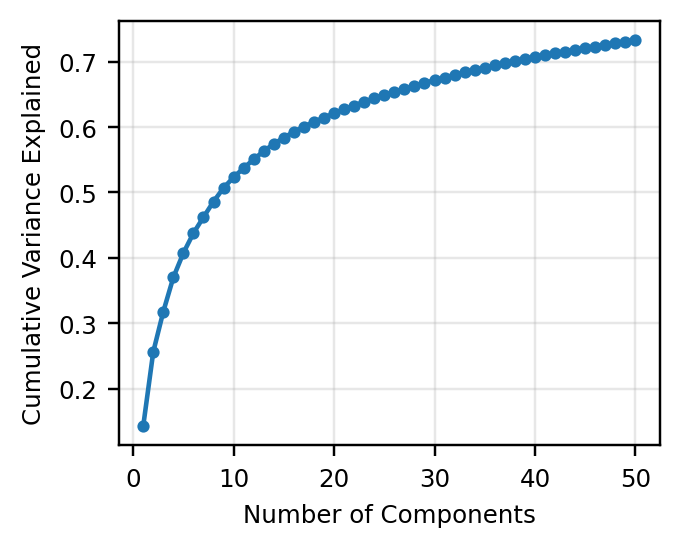

PCA  50 components + whitening
Train Accuracy		Validation Accuracy
    0.9757			0.9722
    0.9868			0.9694
    0.9465			0.9500
    0.9938			0.9944
    0.9549			0.9528

pca.explained_variance_ratio_.cumsum()[[34, 49]] -> [0.6906932 0.7327198]

PCA  35 components + whitening
Train Accuracy		Validation Accuracy
    0.9924			0.9861
    0.9903			0.9944
    0.9910			0.9889
    0.9861			0.9889
    0.9854			0.9917


In [14]:
# === Predictive Model (adapted for /kaggle/working, histeq fc1) ===
from pathlib import Path
import numpy as np, pickle
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment

# ---------- I/O ----------
WORK   = Path("/kaggle/working")
FIGS   = WORK / "Figures";    FIGS.mkdir(parents=True, exist_ok=True)
CACHE  = WORK / ".neu_cache"; CACHE.mkdir(parents=True, exist_ok=True)

FC1_NPY  = WORK / "features_histeq_fc1.npy"
FC1_META = WORK / "features_histeq_fc1.pickle"
LE_PATH  = WORK / "label_encoder.pkl"

assert FC1_NPY.is_file() and FC1_META.is_file(), "fc1 histeq features not found. Generate them first."
assert LE_PATH.is_file(), "label_encoder.pkl not found."

X = np.load(FC1_NPY)
with open(FC1_META, "rb") as f: meta = pickle.load(f)
labels = np.asarray(meta.get("labels_str") or meta.get("labels"))

with open(LE_PATH, "rb") as f: le = pickle.load(f)
y_gt = le.transform(labels)

# ---------- Robust label matcher (Hungarian + safe handling of extra clusters) ----------
def label_matcher(pred_labels, y_true_int):
    pred_labels = np.asarray(pred_labels)
    y_true_int  = np.asarray(y_true_int)
    pred_vals = np.sort(np.unique(pred_labels))
    true_vals = np.sort(np.unique(y_true_int))
    C = contingency_matrix(y_true_int, pred_labels, eps=None)  # (n_true, n_pred)
    r, c = linear_sum_assignment(C.max() - C)                  # maximize matches
    mapping = {pred_vals[c_i]: true_vals[r_i] for r_i, c_i in zip(r, c)}
    # Map any unmatched predicted cluster to the row with max count in its column
    for pv in pred_vals:
        if pv not in mapping:
            col = np.where(pred_vals == pv)[0][0]
            mapping[pv] = true_vals[int(np.argmax(C[:, col]))]
    return np.array([mapping[v] for v in pred_labels], dtype=int)

# ---------- PCA setup + variance curve (like paper) ----------
n_pca = 50
pca    = PCA(n_components=n_pca, svd_solver='full', whiten=True,  random_state=42)
pca_nw = PCA(n_components=n_pca, svd_solver='full', whiten=False, random_state=42)
x     = pca.fit_transform(X)
x_nw  = pca_nw.fit_transform(X)

fig, ax = plt.subplots(figsize=(3.2, 2.6), dpi=220)
ax.plot(range(1, n_pca+1), PCA(n_components=n_pca, whiten=False, svd_solver='full').fit(X)
        .explained_variance_ratio_.cumsum(), '-o', markersize=3)
ax.set_xlabel('Number of Components', fontsize=8)
ax.set_ylabel('Cumulative Variance Explained', fontsize=8)
ax.grid(which='both', alpha=0.3)
ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

# ---------- K-fold cross validation (PCA=50, whitened) ----------
use_cache = True
cache_50 = CACHE / "kmeans_crossval_cache_50c.pickle"

if (not use_cache) or (not cache_50.is_file()):
    rs = np.random.RandomState(seed=3732236083)
    n_splits = 5
    train_acc = np.zeros(n_splits, dtype=float)
    val_acc   = np.zeros(n_splits, dtype=float)

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=int(rs.randint(2**32)))
    splits = kfold.split(x)  # just to get consistent indices

    for i, (train_idx, val_idx) in enumerate(splits):
        fc1train, fc1val = X[train_idx], X[val_idx]
        Ytrain,  Yval    = y_gt[train_idx], y_gt[val_idx]

        pca_cval = PCA(n_components=50, whiten=True, svd_solver='full')
        pca_cval.fit(fc1train)
        xtrain_cval = pca_cval.transform(fc1train)
        xval_cval   = pca_cval.transform(fc1val)

        km = KMeans(n_clusters=7, init='k-means++', n_init=500,
                    random_state=int(rs.randint(2**32))).fit(xtrain_cval)

        labels_train = km.labels_
        labels_val   = km.predict(xval_cval)

        Ypred_train = label_matcher(labels_train, Ytrain)
        Ypred_val   = label_matcher(labels_val,   Yval)

        train_acc[i] = np.mean(Ypred_train == Ytrain)
        val_acc[i]   = np.mean(Ypred_val   == Yval)

    with open(cache_50, "wb") as f:
        pickle.dump({"train_acc": train_acc, "val_acc": val_acc, "n_pca": 50}, f)
else:
    with open(cache_50, "rb") as f:
        obj = pickle.load(f)
        train_acc, val_acc, n_pca = obj["train_acc"], obj["val_acc"], obj["n_pca"]

print('PCA {:>3} components + whitening'.format(50))
print('Train Accuracy\t\tValidation Accuracy')
for tr, va in zip(train_acc, val_acc):
    print("    {:.4f}\t\t\t{:.4f}".format(tr, va))

# ---------- Try fewer components (paper uses 35) ----------
# Show the cumulative variance at 35 and 50, like the paper
pca_all = PCA(whiten=True, svd_solver='full').fit(X)
cumvar = pca_all.explained_variance_ratio_.cumsum()
print("\npca.explained_variance_ratio_.cumsum()[[34, 49]] ->",
      np.array([cumvar[34], cumvar[49]]))

use_cache = True
cache_35 = CACHE / "kmeans_crossval_cache.pickle"

if (not use_cache) or (not cache_35.is_file()):
    rs = np.random.RandomState(seed=2618930764)
    n_splits = 5
    train_acc = np.zeros(n_splits, dtype=float)
    val_acc   = np.zeros(n_splits, dtype=float)
    n_pca = 35

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=int(rs.randint(2**32)))
    splits = kfold.split(x)  # re-use same shape/indices source

    for i, (train_idx, val_idx) in enumerate(splits):
        fc1train, fc1val = X[train_idx], X[val_idx]
        Ytrain,  Yval    = y_gt[train_idx], y_gt[val_idx]

        pca_cval = PCA(n_components=n_pca, whiten=True, svd_solver='full')
        pca_cval.fit(fc1train)
        xtrain_cval = pca_cval.transform(fc1train)
        xval_cval   = pca_cval.transform(fc1val)

        km = KMeans(n_clusters=7, init='k-means++', n_init=500,
                    random_state=int(rs.randint(2**32))).fit(xtrain_cval)

        labels_train = km.labels_
        labels_val   = km.predict(xval_cval)

        Ypred_train = label_matcher(labels_train, Ytrain)
        Ypred_val   = label_matcher(labels_val,   Yval)

        train_acc[i] = np.mean(Ypred_train == Ytrain)
        val_acc[i]   = np.mean(Ypred_val   == Yval)

    with open(cache_35, "wb") as f:
        pickle.dump({"train_acc": train_acc, "val_acc": val_acc, "n_pca": n_pca}, f)
else:
    with open(cache_35, "rb") as f:
        obj = pickle.load(f)
        train_acc, val_acc, n_pca = obj["train_acc"], obj["val_acc"], obj["n_pca"]

print('\nPCA {:>3} components + whitening'.format(n_pca))
print('Train Accuracy\t\tValidation Accuracy')
for tr, va in zip(train_acc, val_acc):
    print("    {:.4f}\t\t\t{:.4f}".format(tr, va))
